In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [5]:
data = np.load("windows_500_50.npz", allow_pickle=True)

X = data["X"]
y = data["y_env"]

print("Dataset shape:", X.shape)

Dataset shape: (3297, 500)


In [6]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Classes:", encoder.classes_)

Classes: ['bridge' 'forest' 'garden' 'lake' 'river']


In [7]:
X = X[..., np.newaxis]

print(X.shape)

(3297, 500, 1)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

In [9]:
def residual_block(x, filters):

    shortcut = x

    x = layers.Conv1D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv1D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same")(shortcut)

    x = layers.Add()([x, shortcut])

    x = layers.Activation("relu")(x)

    return x

In [10]:
def build_resnet(input_shape, num_classes):

    inputs = Input(shape=input_shape)

    x = layers.Conv1D(32, 7, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)

    x = residual_block(x, 32)
    x = residual_block(x, 64)

    x = layers.MaxPooling1D(2)(x)

    x = residual_block(x, 128)
    x = residual_block(x, 128)

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [11]:
model = build_resnet(X_train.shape[1:], len(np.unique(y)))

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 500, 1)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 500, 32)           │             256 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 500, 32)           │             128 │ conv1d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_1 (Conv1D)             │ (None, 500, 32)           │           3,104 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 500, 32)           │             128 │ conv1d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_2 (Conv1D)             │ (None, 500, 32)           │           3,104 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 500, 32)           │             128 │ conv1d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 500, 32)           │               0 │ batch_normalization_2[0][… │
│                               │                           │                 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 500, 32)           │               0 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_3 (Conv1D)             │ (None, 500, 64)           │           6,208 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 500, 64)           │             256 │ conv1d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_4 (Conv1D)             │ (None, 500, 64)           │          12,352 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_4         │ (None, 500, 64)           │             256 │ conv1d_4[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_5 (Conv1D)             │ (None, 500, 64)           │           2,112 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 228,101 (891.02 KB)

 Trainable params: 226,629 (885.27 KB)

 Non-trainable params: 1,472 (5.75 KB)

In [12]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5
)

In [13]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=32,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/60
78/78 ━━━━━━━━━━━━━━━━━━━━ 22s 173ms/step - accuracy: 0.5028 - loss: 1.1822 - val_accuracy: 0.2400 - val_loss: 1.9193 - learning_rate: 0.0010
Epoch 2/60
78/78 ━━━━━━━━━━━━━━━━━━━━ 12s 152ms/step - accuracy: 0.6157 - loss: 0.9627 - val_accuracy: 0.2036 - val_loss: 2.8065 - learning_rate: 0.0010
Epoch 3/60
78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 142ms/step - accuracy: 0.6691 - loss: 0.8414 - val_accuracy: 0.2788 - val_loss: 3.2821 - learning_rate: 0.0010
Epoch 4/60
78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 142ms/step - accuracy: 0.7031 - loss: 0.7429 - val_accuracy: 0.2400 - val_loss: 4.0906 - learning_rate: 0.0010
Epoch 5/60
78/78 ━━━━━━━━━━━━━━━━━━━━ 12s 151ms/step - accuracy: 0.7087 - loss: 0.7278 - val_accuracy: 0.2170 - val_loss: 3.9850 - learning_rate: 0.0010
Epoch 6/60
78/78 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step - accuracy: 0.7391 - loss: 0.6577 - val_accuracy: 0.2545 - val_loss: 3.7203 - learning_rate: 0.0010
Epoch 7/60
78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 147ms/step - accuracy: 0.7731 - loss: 0.

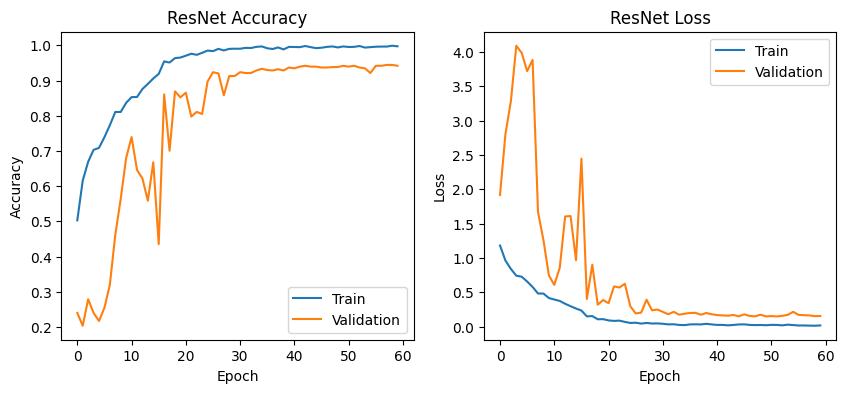

In [14]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("ResNet Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("ResNet Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [15]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9418 - loss: 0.1497
Test Accuracy: 0.9418181777000427


In [16]:
y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


In [17]:
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

              precision    recall  f1-score   support

      bridge       0.95      0.95      0.95       220
      forest       0.93      0.97      0.95       198
      garden       0.89      0.87      0.88       103
        lake       0.96      0.95      0.96       168
       river       0.96      0.93      0.95       136

    accuracy                           0.94       825
   macro avg       0.94      0.94      0.94       825
weighted avg       0.94      0.94      0.94       825



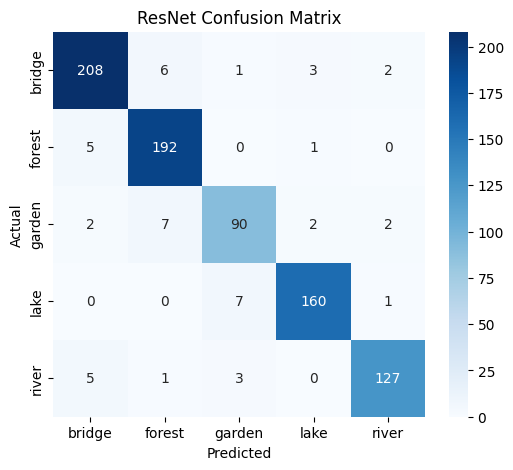

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet Confusion Matrix")

plt.show()

In [19]:
model.save("resnet_environment_model.h5")